In [ ]:
# directional distribution - south side

In [1]:
import pandas as pd
import geopandas as gpd
import shapely
from cartopy import crs
import seaborn as sns
import matplotlib.pyplot as plt
import re
from shapely.wkt import loads
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import altair as alt
#from PIL import Image

In [6]:
commarea = gpd.read_file('comm_area_shapefiles/CHI Community Areas.shp')
commarea.geometry = commarea.geometry.to_crs(epsg=4326)

In [3]:
commarea.COMMUNITY.values

array(['DOUGLAS', 'OAKLAND', 'FULLER PARK', 'GRAND BOULEVARD', 'KENWOOD',
       'LINCOLN SQUARE', 'WASHINGTON PARK', 'HYDE PARK', 'WOODLAWN',
       'ROGERS PARK', 'JEFFERSON PARK', 'FOREST GLEN', 'NORTH PARK',
       'ALBANY PARK', 'PORTAGE PARK', 'IRVING PARK', 'DUNNING',
       'MONTCLARE', 'BELMONT CRAGIN', 'WEST RIDGE', 'HERMOSA', 'AVONDALE',
       'LOGAN SQUARE', 'HUMBOLDT PARK', 'WEST TOWN', 'AUSTIN',
       'WEST GARFIELD PARK', 'EAST GARFIELD PARK', 'NEAR WEST SIDE',
       'NORTH LAWNDALE', 'UPTOWN', 'SOUTH LAWNDALE', 'LOWER WEST SIDE',
       'NEAR SOUTH SIDE', 'ARMOUR SQUARE', 'NORWOOD PARK',
       'NEAR NORTH SIDE', 'LOOP', 'SOUTH SHORE', 'CHATHAM', 'AVALON PARK',
       'SOUTH CHICAGO', 'BURNSIDE', 'CALUMET HEIGHTS', 'ROSELAND',
       'NORTH CENTER', 'PULLMAN', 'SOUTH DEERING', 'EAST SIDE',
       'WEST PULLMAN', 'RIVERDALE', 'HEGEWISCH', 'GARFIELD RIDGE',
       'ARCHER HEIGHTS', 'BRIGHTON PARK', 'MCKINLEY PARK', 'LAKE VIEW',
       'BRIDGEPORT', 'NEW CITY', 'WEST EL

In [1]:
%conda list numpy

# packages in environment at /home/nitomanto/anaconda3/envs/ujp_env:
#
# Name                    Version                   Build  Channel
numpy                     2.2.4           py313hf4aebb8_0  
numpy-base                2.2.4           py313h3fc9231_0  

Note: you may need to restart the kernel to use updated packages.


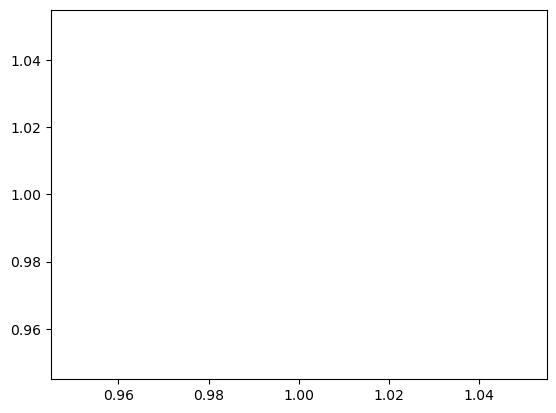

In [3]:
plt.plot(1,1)
plt.show()

/tmp/ipykernel_44893/2823089775.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(commarea.geometry.centroid.x,
/tmp/ipykernel_44893/2823089775.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  commarea.geometry.centroid.y,


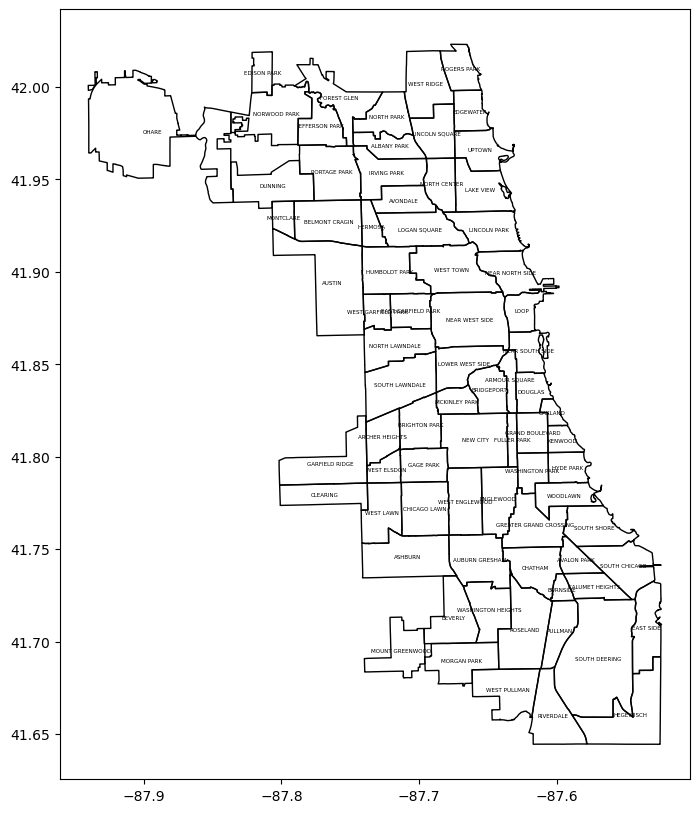

In [10]:
fig, ax = plt.subplots(figsize=(10,10))

commarea.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)
# Add community labels

for x, y, label in zip(commarea.geometry.centroid.x, 
                        commarea.geometry.centroid.y, 
                        commarea["COMMUNITY"]):
    ax.text(x, y, label, fontsize=4, color="black", ha="center", va="center")

plt.show()

/tmp/ipykernel_44893/2507043215.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  commarea_ss = commarea[commarea.geometry.centroid.y <= 41.86]


<Axes: >

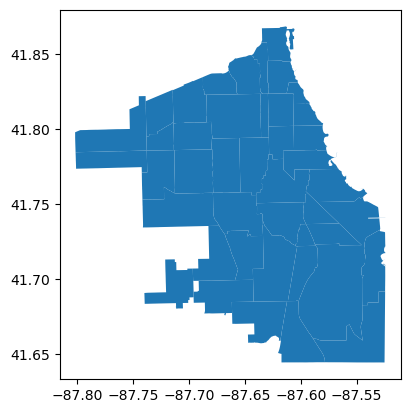

In [17]:
commarea_ss = commarea[commarea.geometry.centroid.y <= 41.86]
commarea_ss = commarea_ss[~commarea_ss.COMMUNITY.isin(['LOOP', 'LOWER WEST SIDE', 'SOUTH LAWNDALE']) ]
commarea_ss.plot()